In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [5]:
data= pd.read_excel("/Users/tam_pr/Desktop/stats/stats/database/dataframe.xlsx")

In [7]:
data.head()

,Sale price,Age,Mileage,Condition,Unnamed: 4,Unnamed: 5
0,(pesos),(years),(miles),Promedio,Excellent,One owner
1,60000,9,112,1,0,1
2,54000,9,159,0,0,1
3,59900,8,192,0,0,1
4,110000,7,90,1,0,0


In [35]:
data.describe()

#data.dropna(axis=0)

data.head()
data.columns

Index(['Sale price', 'Age', 'Mileage', 'Condition', 'Unnamed: 4',
       'Unnamed: 5'],
      dtype='str')

In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 1 to 31
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sale price  31 non-null     object
 1   Age         31 non-null     object
 2   Mileage     31 non-null     object
 3   Condition   31 non-null     object
 4   Unnamed: 4  31 non-null     object
 5   Unnamed: 5  31 non-null     object
dtypes: object(6)
memory usage: 1.6+ KB


Calculate the correlation coeficients of each out value w predictor value. 

then do the mathematical shit to "prove" it
do the outliers treatment 


In [45]:
y = data["Sale price"]
y.dtypes


dtype('O')

In [43]:
y = y.astype(int) #out variable 

age = data["Age"]
age = age.astype(int)

mileage = data["Mileage"]
mileage = mileage.astype(int)
y

,Sale price
1,60000
2,54000
3,59900
4,110000
5,79760
6,78000
7,56000
8,136000
9,125900
10,74000


## Age vs Sale Price

In [76]:
age_saleprice = pd.DataFrame({
    "Age (x)": age,
    "Sale price (y)": y
})
age_saleprice

,Age (x),Sale price (y)
1,9,60000
2,9,54000
3,8,59900
4,7,110000
5,7,79760
6,7,78000
7,7,56000
8,6,136000
9,6,125900
10,6,74000


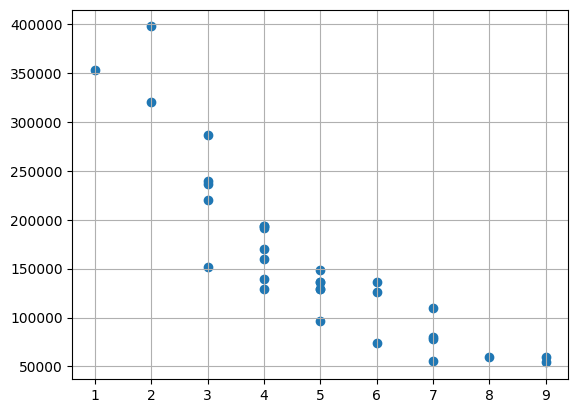

In [51]:
plt.scatter(age,y)
plt.grid()

What this graph is showing us is a relation between the age of a vehicle and its selling price, as we can see, we could say that the older a car is the lower its selling price. 

## Pearson coefficient 

In [84]:
def getPearsonCoefficient (x,y): 
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_xmean = []

    for i in x: 
        x_xmean.append(i-x_mean)

    y_ymean = []
    for i in y:
        y_ymean.append(i-y_mean)

    n = len(x)

    sxy_elements = []
    for i in range(n): 
        sxy_elements.append(x_xmean[i]*y_ymean[i])

    sxy = sum(sxy_elements)

    sxx_elements = []
    for i in range(n):
        sxx_elements.append(x_xmean[i]**2)

    sxx = sum(sxx_elements)

    syy_elements = []
    for i in range(n):
        syy_elements.append(y_ymean[i]**2)

    syy = sum(syy_elements)

    sqrt_sxx = (sxx)**0.5
    sqrt_syy = (syy)**0.5

    r = sxy/(sqrt_sxx*sqrt_syy)
    r = r.astype(float)

    return r



In [ ]:
r_age = getPearsonCoefficient(age,y)
print(r_age)

#check using pandas built in function

age_saleprice.corr(method="pearson")

-0.8724384262540563
                 Age (x)  Sale price (y)
Age (x)         1.000000       -0.872438
Sale price (y) -0.872438        1.000000


## Intepreting Pearson coefficient 

After calculating and comparing with the graph we can confidently say that theres a negative linear relation between the age of the vehicle and the sale price of it. <br>

## Linear regression 

In [ ]:
def getLinearRegression(x,y): 


    return b1, b0